# Task 1: Problem Identification
The dataset represents an *Image Classification* problem because the images are already divided into different folders such as dent, normal, scratch, and stain. Each image belongs to only one category, and the objective is to identify which category an image belongs to.

Image classification is the most suitable problem type for this dataset because the model needs to study visual patterns from the images and predict a single label. For example, if an image contains a scratch, the model should classify it under the scratch category. Similarly, images showing dents or stains should be classified into their respective categories.

This dataset does not represent object detection because there are no bounding boxes showing object locations. It is also not semantic or instance segmentation because pixel-level labeling is not provided. Therefore, image classification is the correct computer vision problem type for this dataset.

In [1]:
import zipfile

zip_path = "part_2_cnn_computer_vision.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
# Import libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Check Classes

dataset_path = "/content/dataset/part_2_cnn_computer_vision/images"

classes = os.listdir(dataset_path)

print("Classes in dataset:")
print(classes)

Classes in dataset:
['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [4]:
# Correct number of classes

classes = ['normal', 'dent', 'scratch', 'stain']

num_classes = len(classes)

print("Number of classes:", num_classes)
print("Classes are:", classes)

Number of classes: 4
Classes are: ['normal', 'dent', 'scratch', 'stain']


In [5]:
# Number of Classes

num_classes = len(classes)

print("Number of classes:", num_classes)

Number of classes: 4


In [6]:
# Number of images in each class

dataset_path = "/content/dataset/part_2_cnn_computer_vision/images"

classes = ['normal', 'dent', 'scratch', 'stain']

for category in classes:
    folder_path = os.path.join(dataset_path, category)
    total_images = len(os.listdir(folder_path))
    print(category, ":", total_images, "images")

normal : 120 images
dent : 120 images
scratch : 120 images
stain : 120 images


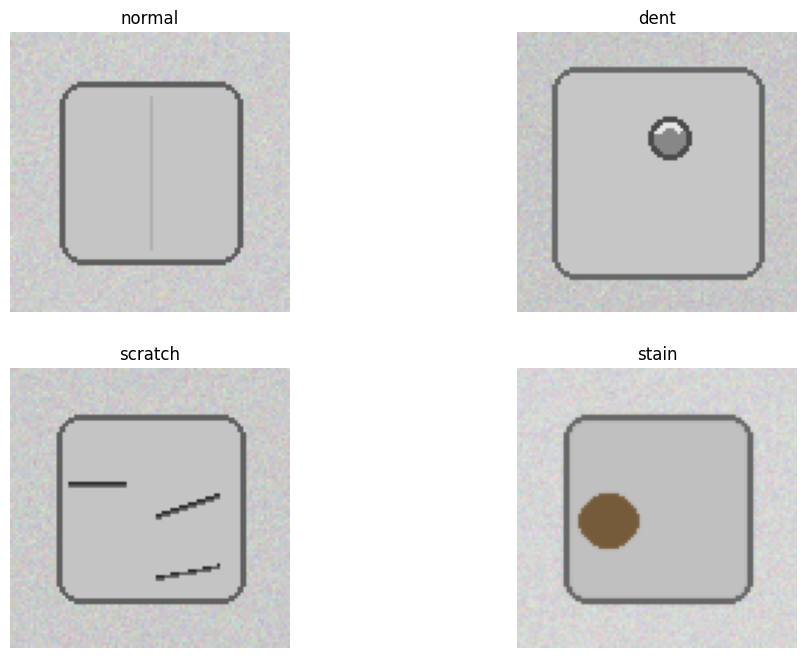

In [7]:
# Show sample images from each class

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis("off")

plt.show()

In [8]:
# Check image dimensions

for category in classes:

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)

    print(category, "image shape:", image.shape)

normal image shape: (96, 96, 3)
dent image shape: (96, 96, 3)
scratch image shape: (96, 96, 3)
stain image shape: (96, 96, 3)


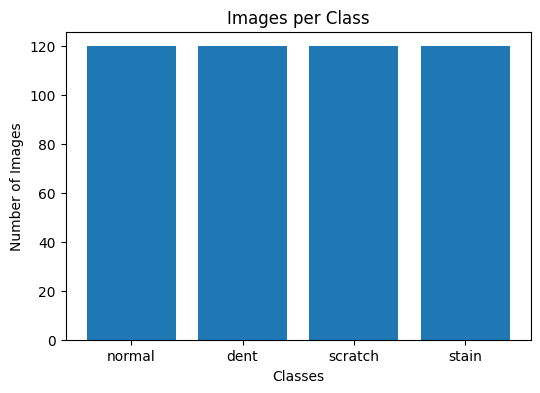

In [9]:
# Task 2 - Check dataset balance

image_count = []

for category in classes:

    folder_path = os.path.join(dataset_path, category)

    total_images = len(os.listdir(folder_path))

    image_count.append(total_images)

plt.figure(figsize=(6,4))

plt.bar(classes, image_count)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.title("Images per Class")

plt.show()

Dataset Analysis

The image dataset is organized into 4 separate categories:

Normal
Dent
Scratch
Stain
Class Distribution

Each category includes the same number of images:

Normal — 120 images
Dent — 120 images
Scratch — 120 images
Stain — 120 images

So, the complete dataset consists of 480 images in total.

Visual Inspection

A few example images from every class were examined to observe the differences between them. The classes show distinct visual patterns, which makes them suitable for training a CNN to recognize and classify the defects accurately.

Image Size

All images have a resolution of 96 × 96 pixels and are stored in RGB format (3 channels). Because the image dimensions are uniform across the dataset, preprocessing and model training become more straightforward.

Balance Check

The dataset is evenly distributed, as every class has exactly 120 images. Since no class has more samples than another, the dataset does not suffer from class imbalance, which supports fair learning during model training.

In [10]:
# Task 3 - Image Preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
img_size = (96, 96)

# Batch size
batch_size = 32

# Data generator with normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Preprocessing completed successfully!")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Preprocessing completed successfully!


Data Preprocessing

Before training the CNN model, the images were prepared through preprocessing steps. Every image was adjusted to a uniform size of 96 × 96 pixels, ensuring consistency across the dataset. The pixel intensities were then scaled to a range of 0 to 1, which helps the model train more efficiently.

The dataset was split into training and testing (validation) sets in an 80:20 ratio. To make the model more robust and prevent overfitting, image augmentation methods were used, including rotation, zoom, and horizontal flipping. These transformations create slight variations in the training images and help the model generalize better.

In [11]:
# TASK 4 - CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Create CNN model
model = Sequential()

# First Convolution + Pooling Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution + Pooling Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

CNN Model Description

A Convolutional Neural Network (CNN) was created to identify and classify images into the four classes: normal, dent, scratch, and stain. The model was implemented using TensorFlow / Keras to automatically learn visual features from the dataset.

The architecture consists of several convolutional layers, which capture important patterns such as edges, textures, and defect shapes from the images. These layers are followed by pooling layers, which reduce the spatial size of the feature maps and help lower computational cost.

The ReLU activation function was applied in hidden layers to introduce non-linearity, allowing the network to learn complex image patterns. After the convolution and pooling stages, a flatten layer converts the extracted features into a one-dimensional vector.

For final classification, dense (fully connected) layers were added to process the extracted features. A dropout layer was also included to minimize overfitting by randomly deactivating some neurons during training. The last layer uses the softmax activation function to assign the input image to one of the four categories.

The network was compiled with the Adam optimizer, categorical crossentropy as the loss function, and accuracy as the main metric for evaluating model performance.

In [12]:
# TASK 5 - Model Training

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 528ms/step - accuracy: 0.2917 - loss: 1.8874 - val_accuracy: 0.2500 - val_loss: 1.3826
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 420ms/step - accuracy: 0.3750 - loss: 1.3504 - val_accuracy: 0.4375 - val_loss: 1.3118
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 0.5339 - loss: 1.2037 - val_accuracy: 0.5312 - val_loss: 1.1454
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 532ms/step - accuracy: 0.5807 - loss: 1.0231 - val_accuracy: 0.6042 - val_loss: 0.9751
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 466ms/step - accuracy: 0.6146 - loss: 0.8750 - val_accuracy: 0.5729 - val_loss: 0.9024
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 537ms/step - accuracy: 0.6901 - loss: 0.7530 - val_accuracy: 0.6458 - val_loss: 0.7678
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 406ms/step - accuracy: 0.7031 - loss: 0.6919 - val_accuracy: 0.6667 - val_loss: 0.6939
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 437ms/step - accuracy: 0.7526 - loss: 0.5912 - val_accuracy: 0.

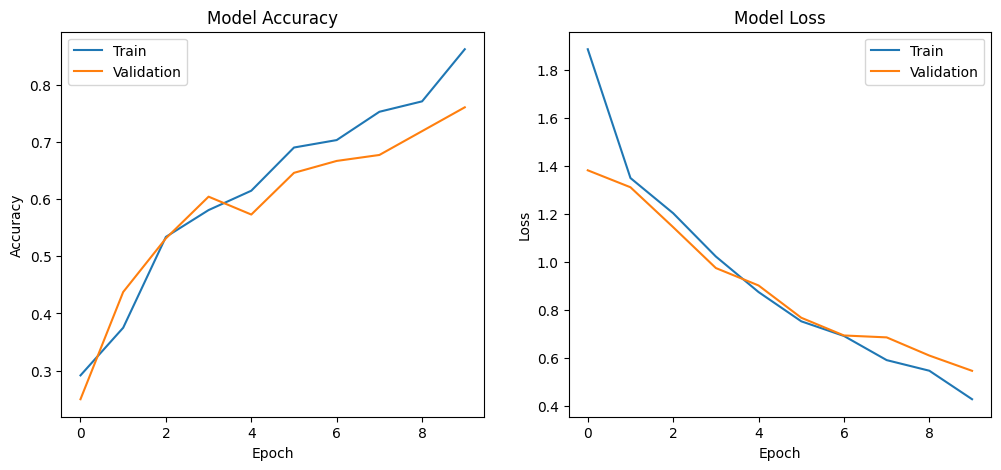

In [13]:
# Accuracy and Loss Curves

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")
plt.show()

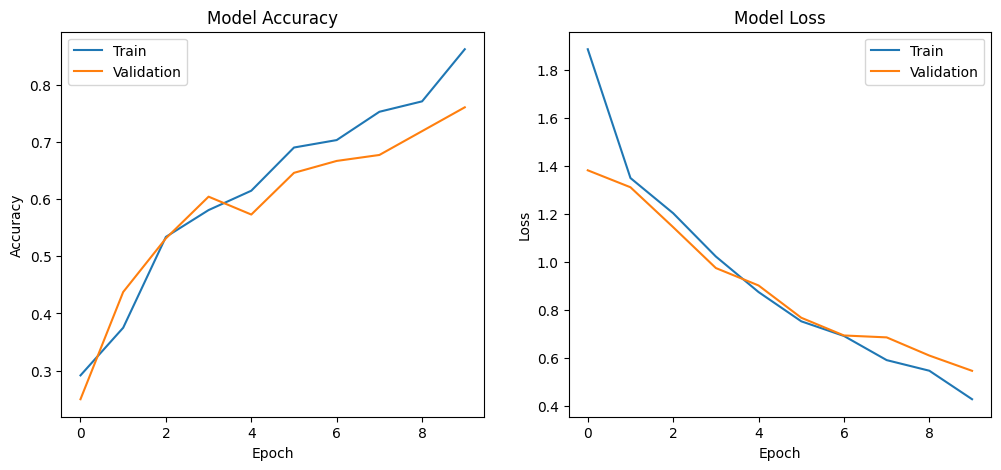

In [14]:
# Accuracy and Loss Curves

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step


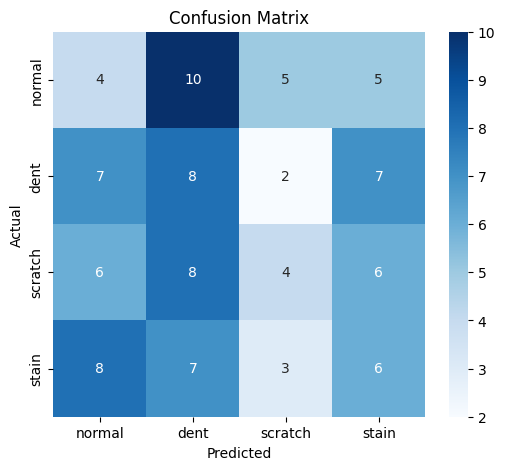

In [15]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Reset test data
test_data.reset()

# Predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save image
plt.savefig("confusion_matrix.png")

plt.show()

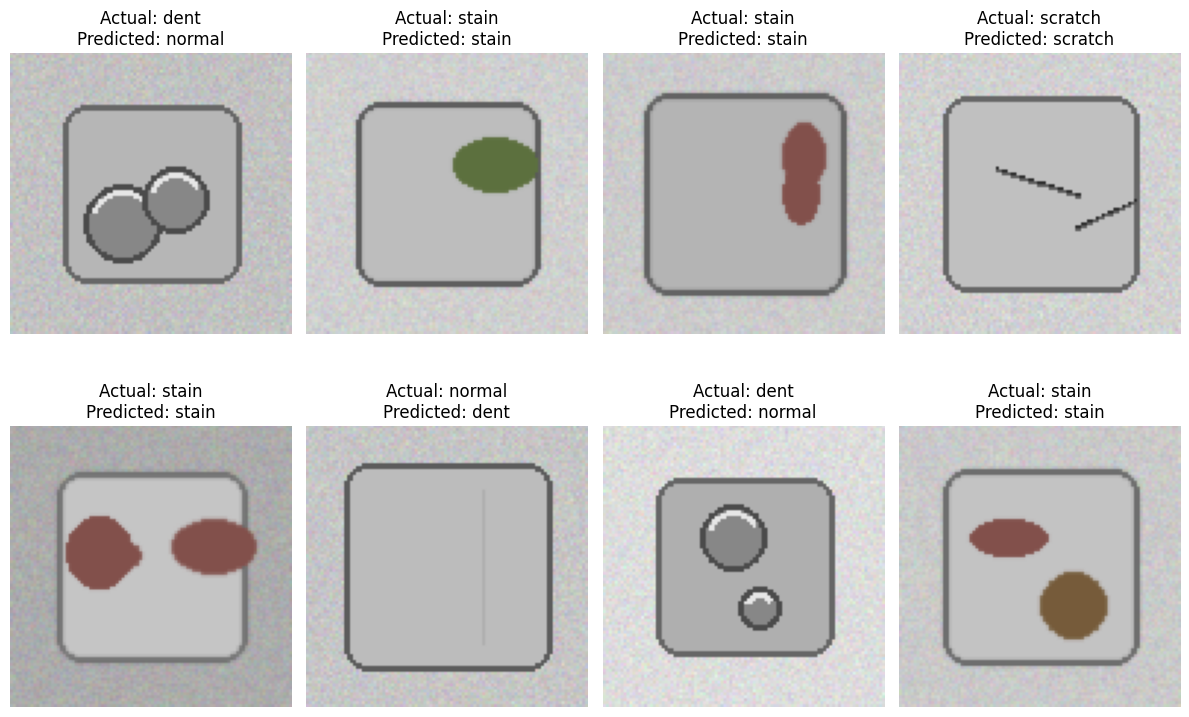

In [16]:
# Sample Predictions on Test Images

import random

plt.figure(figsize=(12,8))

for i in range(8):

    category = random.choice(classes)

    folder_path = os.path.join(dataset_path, category)

    image_name = random.choice(os.listdir(folder_path))

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(image_rgb, img_size)
    normalized_image = resized_image / 255.0

    prediction = model.predict(np.expand_dims(normalized_image, axis=0), verbose=0)

    predicted_class = classes[np.argmax(prediction)]

    plt.subplot(2,4,i+1)
    plt.imshow(image_rgb)
    plt.title(f"Actual: {category}\nPredicted: {predicted_class}")
    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()

Model Training and Evaluation

The CNN model was trained on the prepared image dataset and tested using the validation set. During training, both training accuracy and validation accuracy increased over multiple epochs, while the loss values gradually decreased. This indicates that the model was able to learn meaningful visual features from the images.

The performance of the model was assessed using the following methods:

Training and validation accuracy/loss graphs to observe learning progress over time
Confusion matrix to check how well the model classified each image category
Sample predictions on test images to verify the model’s output on unseen data